In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pygpufit.gpufit as gf
from scipy.optimize import curve_fit

In [2]:
def gaussian_peak_1d(x, p):
    """
    Generates a 1D Gaussian peak.
    See http://gpufit.readthedocs.io/en/latest/fit_model_functions.html#d-gaussian-function

    :param x: x grid position values
    :param p: parameters (amplitude, center position, width, offset)
    :return: Gaussian peak
    """
    
    return p[0] * np.exp(-(x - p[1])**2 / (2 * p[2]**2)) + p[3]

In [3]:
xV = np.linspace(-10,10,1000, dtype=np.float32)
yV = gaussian_peak_1d(xV, [10, 2, 1, 1])
yV = np.random.poisson(yV).astype(np.float32)



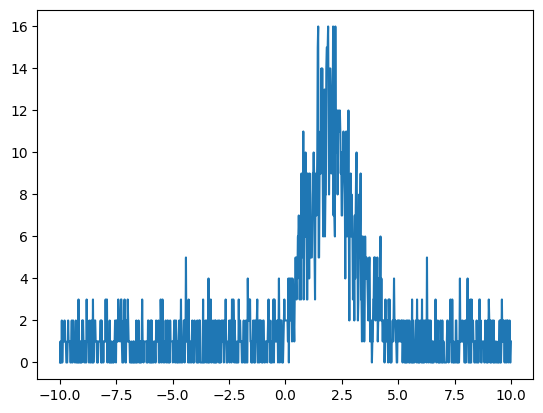

In [4]:
plt.plot(xV, yV)

In [5]:
model = gf.ModelID.GAUSS_1D

params = np.array([5, 0, 1, 0], dtype=np.float32).reshape(1,-1)

tolerance = 1e-30
max_n_iterations = 1000
estimator_id = gf.EstimatorID.LSE

In [6]:
data = np.reshape(yV, (1,-1))

parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(data, None, model, params, tolerance, max_n_iterations, None, estimator_id, xV)


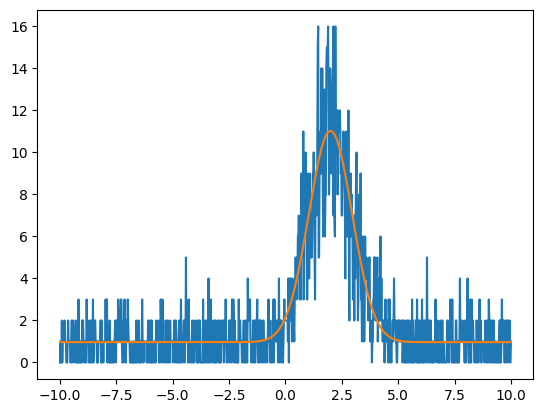

In [7]:
plt.plot(xV, yV)
plt.plot(xV, gaussian_peak_1d(xV, *parameters_gauss))

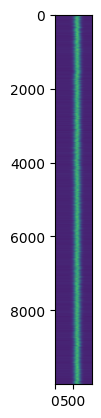

In [8]:
howMany = 10000
numParams = 4

dx = np.random.normal(0, 1)

yV_2d = np.zeros((howMany, xV.size), dtype=np.float32)
params_2d = np.zeros((howMany, 4), dtype=np.float32)

params_2d[:,0] = 50 + np.random.normal(0,5, size=howMany)
params_2d[:,1] = 2 + np.random.normal(0,0.7, size=howMany)
params_2d[:,2] = 1 + np.random.normal(0,0.1, size=howMany)
params_2d[:,3] = 4 + np.random.normal(0,2, size=howMany)

for i in range(howMany):
    yV_2d[i,:] = gaussian_peak_1d(xV, params_2d[i, :])

yV_2d -= np.min(yV_2d)

plt.imshow(yV_2d)


# plt.plot(params_2d[:,1])


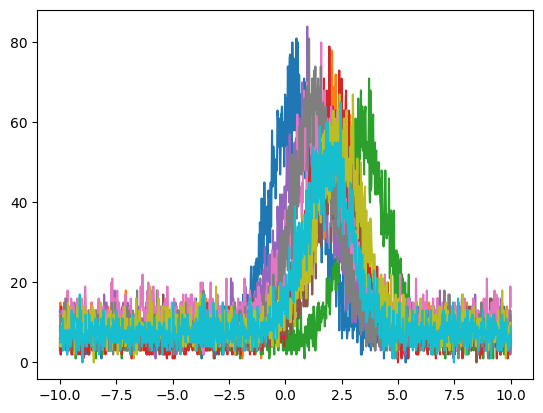

In [9]:
yV_2d = np.random.poisson(yV_2d).astype(np.float32)

for idx in np.random.choice(howMany, size=10):
    plt.plot(xV, yV_2d[idx, :])
plt.show()



In [10]:
params_initial = np.tile([10,2,1,5], howMany).reshape(howMany, -1).astype(np.float32)

params_initial

array([[10.,  2.,  1.,  5.],
       [10.,  2.,  1.,  5.],
       [10.,  2.,  1.,  5.],
       ...,
       [10.,  2.,  1.,  5.],
       [10.,  2.,  1.,  5.],
       [10.,  2.,  1.,  5.]], shape=(10000, 4), dtype=float32)

In [11]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(yV_2d, None, model, params_initial, tolerance, max_n_iterations, None, estimator_id, xV)

print(time_gauss)

0.2757692000013776


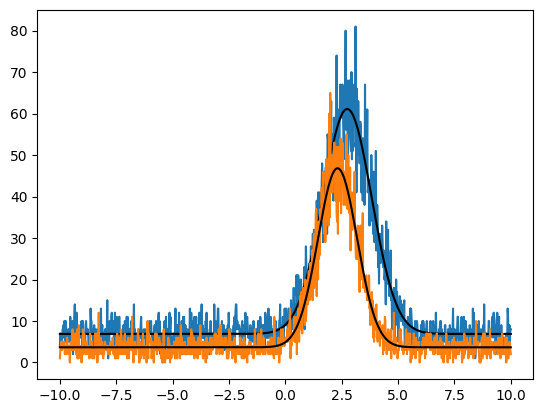

In [12]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, gaussian_peak_1d(xV, parameters_gauss[idx, :]), color='k')
plt.show()


In [13]:
wrongIndices = np.argwhere(np.abs(params_2d[:,1] - parameters_gauss[:,1]) > 2)

In [14]:
wrongIndices

array([[ 743],
       [7199]])

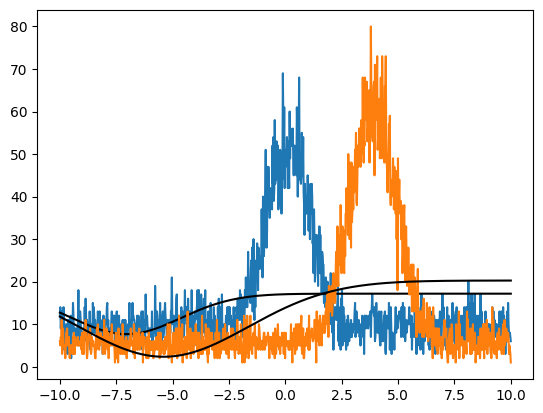

In [15]:
for idx in wrongIndices.flatten():
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, gaussian_peak_1d(xV, parameters_gauss[idx, :]), color='k')

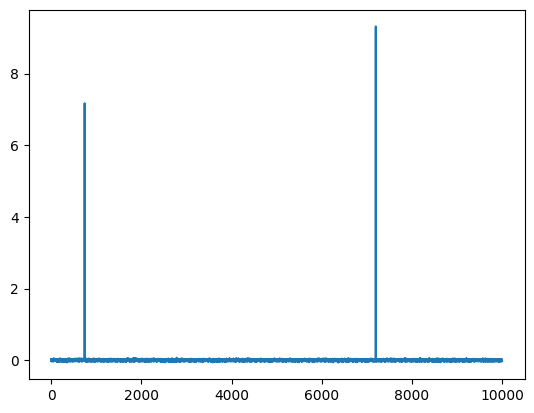

In [16]:
plt.plot(params_2d[:,1] - parameters_gauss[:,1])

In [17]:
def lorentzian_peak_1d(x, p):    
    return p[0] * p[2]**2 / ((x-p[1])**2 + p[2]**2) + p[3]

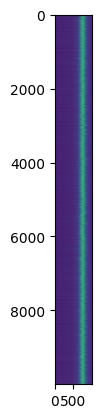

In [18]:
yV_2d = np.zeros((howMany, xV.size), dtype=np.float32)
params_2d = np.zeros((howMany, 4), dtype=np.float32)

params_2d[:,0] = 50 + np.random.normal(0,5, size=howMany)
params_2d[:,1] = 5 + np.random.normal(0,0.7, size=howMany)
params_2d[:,2] = 1 + np.random.normal(0,0.1, size=howMany)
params_2d[:,3] = 4 + np.random.normal(0,2, size=howMany)

for i in range(howMany):
    yV_2d[i,:] = lorentzian_peak_1d(xV, params_2d[i, :])

yV_2d -= np.min(yV_2d)

plt.imshow(yV_2d)

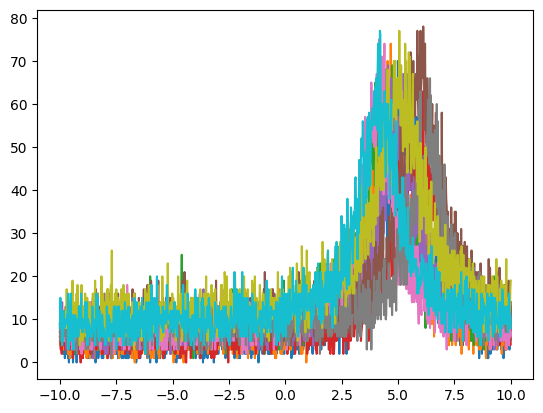

In [19]:
yV_2d = np.random.poisson(yV_2d).astype(np.float32)

for idx in np.random.choice(howMany, size=10):
    plt.plot(xV, yV_2d[idx, :])
plt.show()

In [20]:
model = gf.ModelID.CAUCHY_LORENTZ_1D

params_initial = np.tile([50,5,1,5], howMany).reshape(howMany, -1).astype(np.float32)

params_initial

array([[50.,  5.,  1.,  5.],
       [50.,  5.,  1.,  5.],
       [50.,  5.,  1.,  5.],
       ...,
       [50.,  5.,  1.,  5.],
       [50.,  5.,  1.,  5.],
       [50.,  5.,  1.,  5.]], shape=(10000, 4), dtype=float32)

In [21]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(yV_2d, None, model, params_initial, tolerance, max_n_iterations, None, estimator_id, xV)

print(time_gauss)

0.32678089999899385


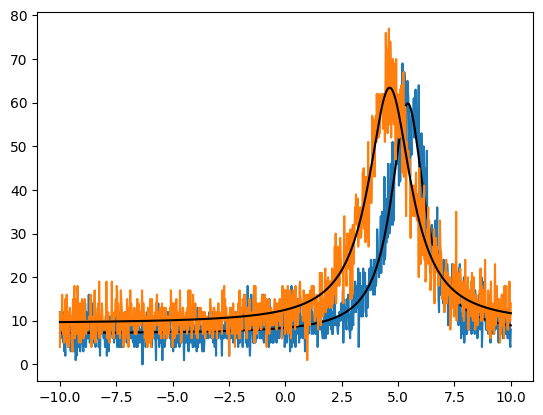

In [22]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, lorentzian_peak_1d(xV, parameters_gauss[idx, :]), color='k')
plt.show()

In [23]:
def DHO_peak_1d(x, p):
    """
    Generates a 1D Gaussian peak.
    See http://gpufit.readthedocs.io/en/latest/fit_model_functions.html#d-gaussian-function

    :param x: x grid position values
    :param p: parameters (amplitude, center position, width, offset)
    :return: Gaussian peak
    """
    
    return p[0] / np.pi * (2 * p[2] * p[1]**2) / ((x**2 - p[1]**2)**2 + (2 * p[2] * x)**2 ) + p[3]


def DHO_peak_1d_scipy(x, A, x0, gamma, y0):
    """
    Generates a 1D Gaussian peak.
    See http://gpufit.readthedocs.io/en/latest/fit_model_functions.html#d-gaussian-function

    :param x: x grid position values
    :param p: parameters (amplitude, center position, width, offset)
    :return: Gaussian peak
    """
    
    return A / np.pi * (2 * gamma * x0**2) / ((x**2 - x0**2)**2 + (2 * gamma * x)**2 ) + y0

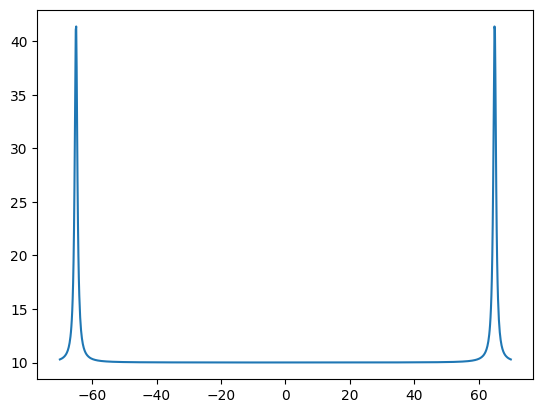

In [24]:
xV = np.linspace(-70,70, 1024, dtype=np.float32)

plt.plot(xV, DHO_peak_1d(xV, [100, 65, 0.5, 10]))

In [25]:
import sympy
# syinit_printing(use_unicode=True)

In [26]:
A, x, x0, gamma, y0 = sympy.symbols('A x x0 gamma y0')

In [27]:
dho = A / sympy.pi * (2 * x0**2 * gamma) / ((x**2 - x0**2)**2 + (2 * gamma * x)**2) + y0


dho

2*A*gamma*x0**2/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2)) + y0

In [28]:
ddA = sympy.diff(dho, A)

ddA

2*gamma*x0**2/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2))

In [29]:
dd_x0 = sympy.diff(dho, x0)

dd_x0

8*A*gamma*x0**3*(x**2 - x0**2)/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2)**2) + 4*A*gamma*x0/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2))

In [30]:
ddgamma = sympy.diff(dho, gamma)

ddgamma

-16*A*gamma**2*x**2*x0**2/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2)**2) + 2*A*x0**2/(pi*(4*gamma**2*x**2 + (x**2 - x0**2)**2))

In [31]:
ddy0 = sympy.diff(dho, y0)

ddy0

1

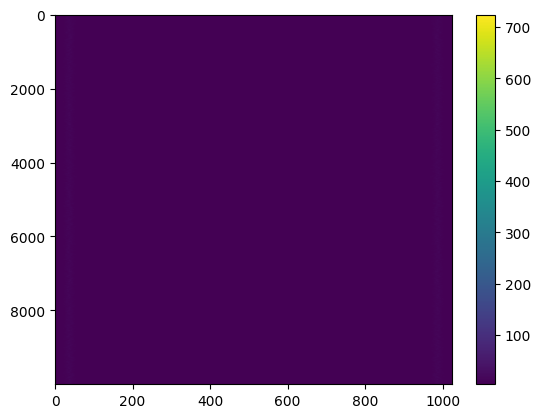

In [32]:
howMany = 10000

yV_2d = np.zeros((howMany, xV.size), dtype=np.float32)
params_2d = np.zeros((howMany, 4), dtype=np.float32)

params_2d[:,0] = np.abs(50 + np.random.normal(0,5, size=howMany))
params_2d[:,1] = 65 + np.random.normal(0,1, size=howMany)
params_2d[:,2] = np.abs(0.3 + np.random.normal(0,0.1, size=howMany))
params_2d[:,3] = 4 #+ np.random.normal(0,2, size=howMany)

for i in range(howMany):
    yV_2d[i,:] = DHO_peak_1d(xV, params_2d[i, :])

# yV_2d -= np.min(yV_2d)

plt.imshow(yV_2d, aspect='auto')
plt.colorbar()
plt.show()

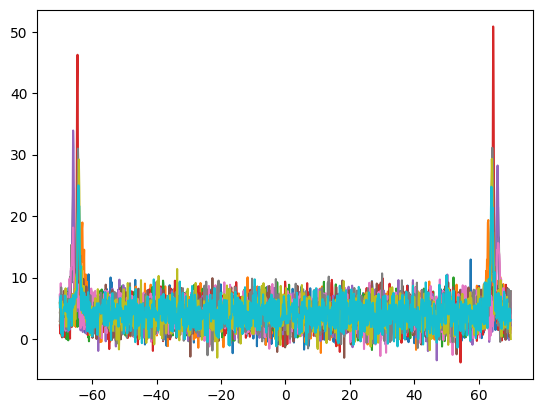

In [33]:
yV_2d += np.random.normal(0,2,size=yV_2d.shape)

for idx in np.random.choice(howMany, size=10):
    plt.plot(xV, yV_2d[idx, :])
plt.show()

In [34]:
model = gf.ModelID.DHO_1D_NUM

params_initial = np.tile([500,65,2,5], howMany).reshape(howMany, -1).astype(np.float32)

In [35]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(yV_2d, None, model, params_initial, tolerance, max_n_iterations, None, estimator_id, xV)
print(time_gauss)

1.28833239999949


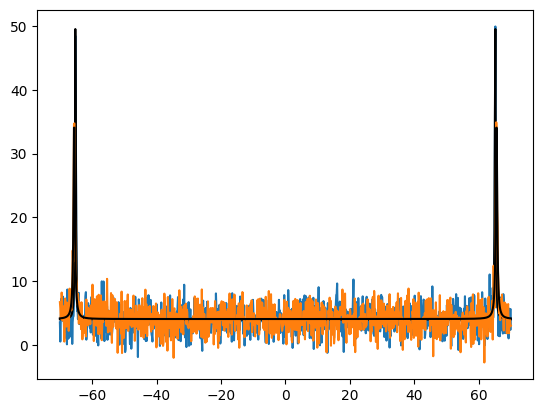

In [36]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, DHO_peak_1d(xV, parameters_gauss[idx, :]), color='k')
plt.show()

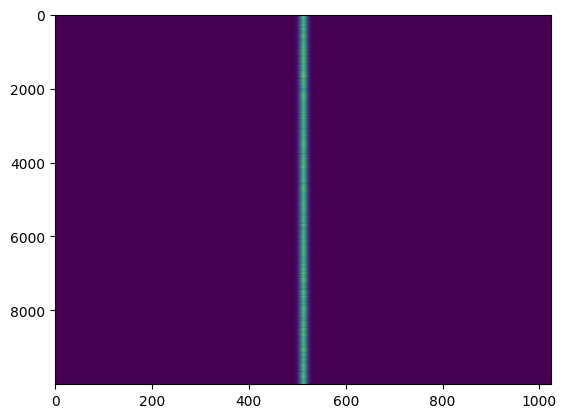

In [37]:
yV_2d = np.zeros((howMany, xV.size), dtype=np.float32)
params_2d = np.zeros((howMany, 4), dtype=np.float32)

params_2d[:,0] = np.abs(5 + np.random.normal(0,1, size=howMany))
params_2d[:,1] = 20 + np.random.normal(0,1, size=howMany)
params_2d[:,2] = np.abs(0.2 + np.random.normal(0,0.05, size=howMany))
params_2d[:,3] = 0 + np.random.normal(0,1, size=howMany)

for i in range(howMany):
    yV_2d[i,:] = DHO_peak_1d(xV, params_2d[i, :])
    yV_2d[i,:] += gaussian_peak_1d(xV, [np.random.uniform(500,2000), 0, 0.8, 0])

# yV_2d -= np.min(yV_2d)

plt.imshow(yV_2d, aspect='auto')

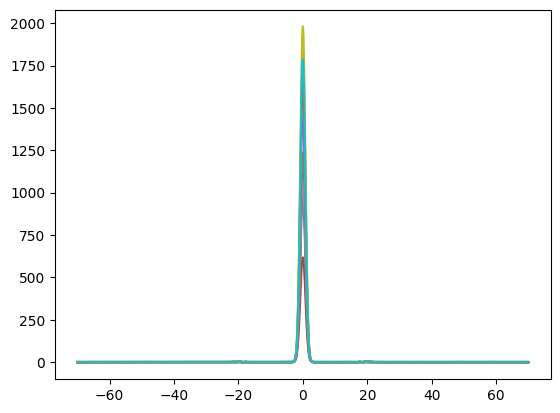

In [38]:
yV_2d += np.random.normal(loc=0, scale=0.1, size=(howMany, xV.size))

for idx in np.random.choice(howMany, size=10):
    plt.plot(xV, yV_2d[idx, :])
plt.show()

In [39]:
startPNT = np.argmin(np.abs(xV + 5))
endPNT = np.argmin(np.abs(xV - 5))
weights = np.ones_like(yV_2d)

weights[:, startPNT:endPNT] = 0


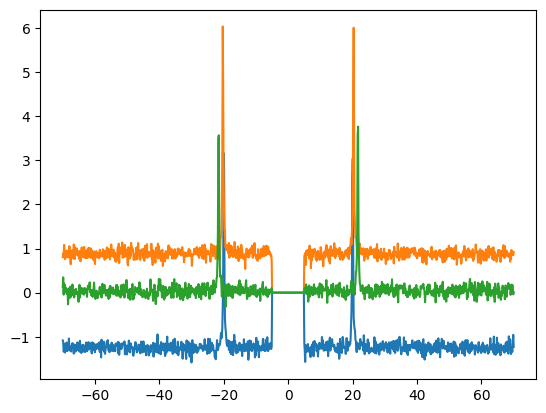

In [40]:
dummy_Y = yV_2d.copy()
dummy_Y[:, startPNT:endPNT] = 0

for idx in np.random.choice(howMany, size=3):
    plt.plot(xV, dummy_Y[idx, :])
plt.show()

In [41]:
params_initial = np.tile([50,20,2,5], howMany).reshape(howMany, -1).astype(np.float32)

parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(yV_2d, weights, gf.ModelID.DHO_1D, params_initial, tolerance, max_n_iterations, None, estimator_id, xV)
print(time_gauss)

0.49043499999970663


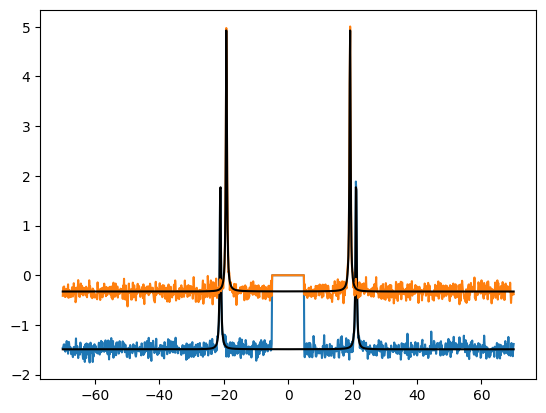

In [42]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, dummy_Y[idx, :])
    plt.plot(xV, DHO_peak_1d(xV, parameters_gauss[idx, :]), color='k')
plt.show()

In [43]:
model = gf.ModelID.DHO_1D_NUM

parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(yV_2d, weights, model, params_initial, tolerance, max_n_iterations, None, estimator_id, xV)
print(time_gauss)

1.0989707000007911


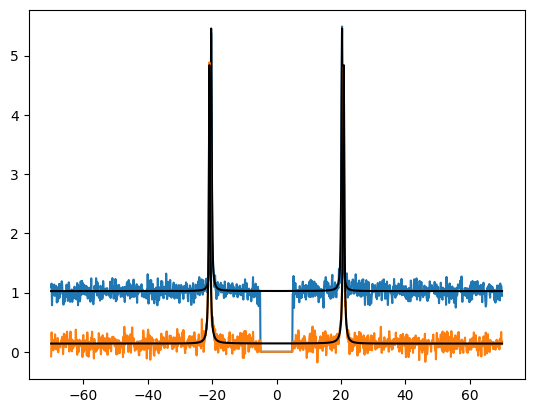

In [44]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, dummy_Y[idx, :])
    plt.plot(xV, DHO_peak_1d(xV, parameters_gauss[idx, :]), color='k')
plt.show()

[ 6.59262186 18.53843732  0.19670361  1.20416042]


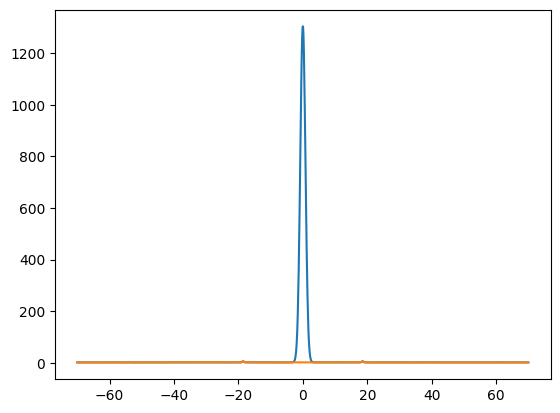

In [45]:
scipy_sigma = np.ones_like(xV)
scipy_sigma[startPNT:endPNT] = 1e7

popt, pcov = curve_fit(DHO_peak_1d_scipy, xV, yV_2d[0,:], params_initial[0,:], sigma=scipy_sigma)

print(popt)
plt.plot(xV, yV_2d[0,:])
plt.plot(xV, DHO_peak_1d_scipy(xV, *popt))
plt.show()

In [46]:
%%time

results = []

for idx in range(howMany):
    try:
        popt, pcov = curve_fit(DHO_peak_1d_scipy, xV, yV_2d[idx,:], params_initial[idx,:], sigma=scipy_sigma)
        results.append(popt)
    except RuntimeError:
        results.append(params_initial[idx,:])
    

CPU times: total: 10.5 s
Wall time: 10.5 s


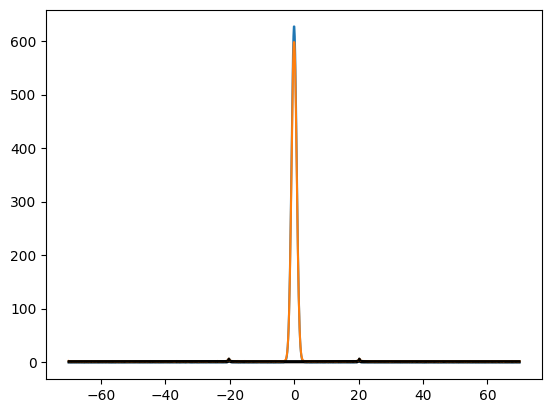

In [47]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, DHO_peak_1d_scipy(xV, *results[idx]), color='k')
plt.show()

In [48]:
constraints_bottom = [0, 2, 0.1, -10]
constraints_top = [np.inf, 70,5,100]

constraints = np.dstack([constraints_bottom, constraints_top]).astype(np.float32).flatten()

constraints = np.tile(constraints, howMany).reshape(howMany, -1)

constraint_type = np.full((params_initial.shape[-1]), gf.ConstraintType.LOWER_UPPER, dtype=np.int32)

constraints[0,:]

array([  0. ,   inf,   2. ,  70. ,   0.1,   5. , -10. , 100. ],
      dtype=float32)

In [49]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit_constrained(yV_2d, weights, gf.ModelID.DHO_1D_NUM, params_initial, constraints, constraint_type, tolerance, max_number_iterations=max_n_iterations, estimator_id=estimator_id, user_info=xV)

time_gauss

1.369119499999215

In [50]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit_constrained(yV_2d, weights, gf.ModelID.DHO_1D, params_initial, constraints, constraint_type, tolerance, max_number_iterations=max_n_iterations, estimator_id=estimator_id, user_info=xV)

time_gauss

0.9446521000008943

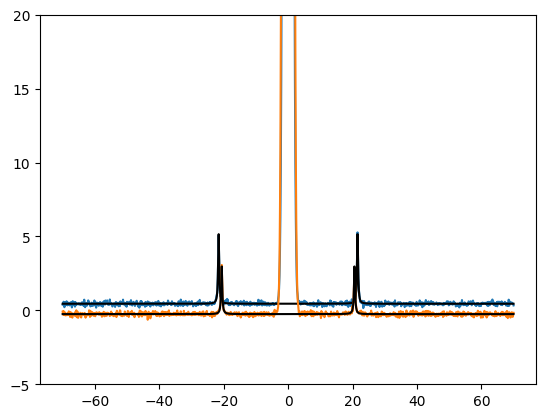

In [51]:
for idx in np.random.choice(howMany, size=2):
    plt.plot(xV, yV_2d[idx, :])
    plt.plot(xV, DHO_peak_1d(xV, parameters_gauss[idx, :]), color='k')

plt.ylim(-5,20)
plt.show()

In [52]:
from SMDutil import SMD
import pathlib

In [53]:
real_data = SMD(pathlib.Path(r"\\temp-svr\Shared\Bertz\2024\20240819\ppLiNbO3_ND0_50xNA095_circ_XYZ_1_brillouin_processed_processed.hdf5"))

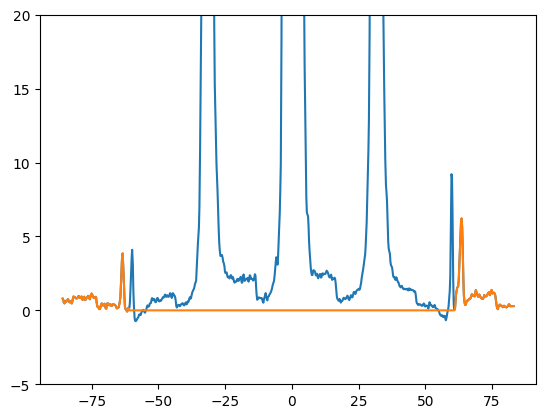

In [54]:
brillouinData = real_data.brillouinChannel.displayData
shift = real_data.brillouinChannel.shift.astype(np.float32)

brillouinData = brillouinData.reshape(np.prod(brillouinData.shape[0:-1]), -1).astype(np.float32)

plt.plot(shift, brillouinData[0,:])
plt.ylim(-5, 20)

startX = np.argmin(np.abs(shift +61))
endX = np.argmin(np.abs(shift - 61))

startX2 = np.argmin(np.abs(shift +70))
endX2 = np.argmin(np.abs(shift - 70))

masked = brillouinData[0,:].copy()
masked[startX:endX] = 0

# masked[0:startX2] = 0
# masked[endX2:] = 0

plt.plot(shift, masked)

In [55]:
fit_data = brillouinData 
fit_x = shift
weights = np.ones_like(fit_data)
weights[:, startX:endX] = 0

params_initial = np.tile(np.array([15, 63.5, 0.5, 0.1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)

constraints_bottom = [0, 60, 0.01, -10]
constraints_top = [np.inf, 70,5,100]

constraints = np.dstack([constraints_bottom, constraints_top]).astype(np.float32).flatten()

constraints = np.tile(constraints, fit_data.shape[0]).reshape(fit_data.shape[0], -1)

constraint_type = np.full((params_initial.shape[-1]), gf.ConstraintType.LOWER_UPPER, dtype=np.int32)

constraints[0,:]

array([ 0.e+00,     inf,  6.e+01,  7.e+01,  1.e-02,  5.e+00, -1.e+01,
        1.e+02], dtype=float32)

In [56]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(fit_data, weights, gf.ModelID.DHO_1D, params_initial, tolerance, max_number_iterations=max_n_iterations, estimator_id=estimator_id, user_info=fit_x)

time_gauss

0.15834499999982654

In [57]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit_constrained(fit_data, weights, gf.ModelID.DHO_1D_NUM, params_initial, constraints, constraint_type, tolerance, max_number_iterations=max_n_iterations, estimator_id=estimator_id, user_info=fit_x)

time_gauss

0.1615261000006285

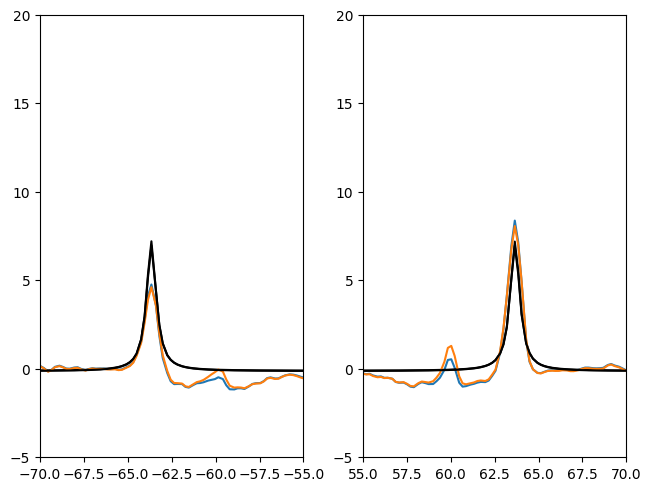

In [58]:
fig, axes = plt.subplots(ncols=2, layout='constrained')

for idx in np.random.choice(howMany, size=2):
    for ax in axes:
        ax.plot(fit_x, fit_data[idx, :])
        ax.plot(fit_x, DHO_peak_1d(fit_x, parameters_gauss[idx, :]), color='k')

axes[0].set_ylim(-5, 20)
axes[0].set_xlim(-70,-55)

axes[1].set_ylim(-5, 20)
axes[1].set_xlim(55,70)

plt.show()


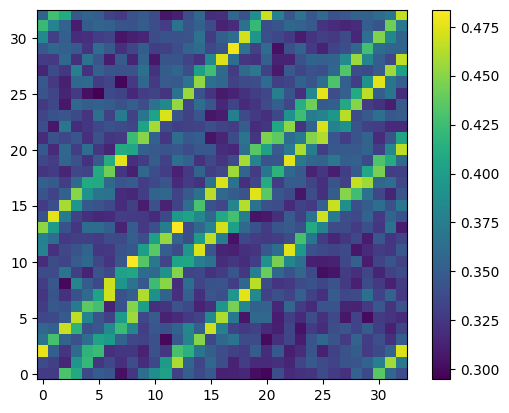

In [59]:
fit_result = parameters_gauss.reshape((real_data.brillouinChannel.displayData.shape[0:-1] + (-1,)))


plt.imshow(fit_result[10,:,:,2], origin='lower')
plt.colorbar()

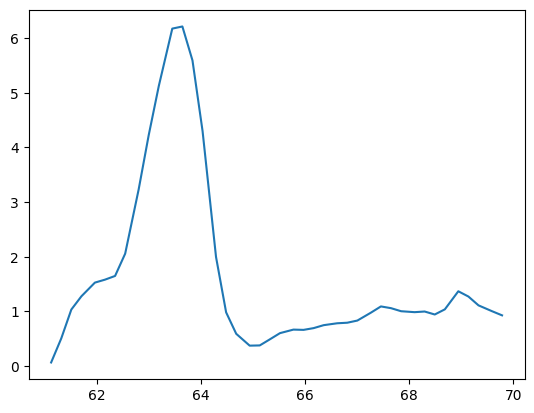

In [60]:
startX2 = np.argmin(np.abs(shift - 61))
endX2 = np.argmin(np.abs(shift - 70))

cropX = np.array(shift[startX2:endX2])
cropData = np.array(fit_data[:, startX2:endX2])

plt.plot(cropX, cropData[0,:])




In [61]:
params_initial = np.tile(np.array([15, 63.5, 0.5, 0.1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)

In [62]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(cropData, None, gf.ModelID.DHO_1D_NUM, params_initial, tolerance, 1000, estimator_id=estimator_id, user_info=cropX)

chi_squares_gauss

array([ 8.897686 ,  8.378595 ,  8.2686615, ..., 10.242013 ,  9.903546 ,
        9.9246235], shape=(11979,), dtype=float32)

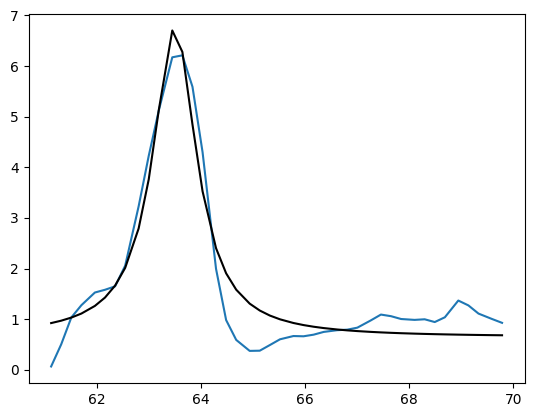

In [63]:
plt.plot(cropX, cropData[0,:])
plt.plot(cropX, DHO_peak_1d(cropX, parameters_gauss[0, :]), color='k')

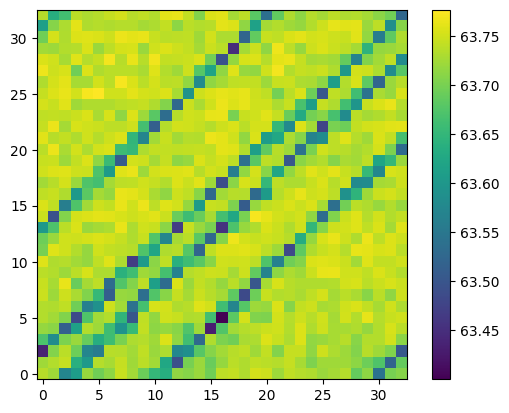

In [64]:
fit_result = parameters_gauss.reshape((real_data.brillouinChannel.displayData.shape[0:-1] + (-1,)))


plt.imshow(fit_result[10,:,:,1], origin='lower')
plt.colorbar()

In [65]:
startX = np.argmin(np.abs(shift - 61))
endX = np.argmin(np.abs(shift - 70))
data_X = np.tile(shift[startX:endX], fit_data.shape[0]).reshape(fit_data.shape[0], -1)

startX2 = np.argmin(np.abs(shift + 61))
endX2 = np.argmin(np.abs(shift + 70))
data_X2 = np.tile(shift[endX2:startX2], fit_data.shape[0]).reshape(fit_data.shape[0], -1)

data_X = np.stack([data_X, data_X2]).reshape(fit_data.shape[0]*2, -1)

cropData = np.array(fit_data[:, startX:endX])
cropData2 = np.array(fit_data[:, endX2:startX2])

data_Y = np.stack([cropData, cropData2]).reshape(fit_data.shape[0]*2, -1)

params_initial = np.tile(np.array([15, 63.5, 0.5, 0.1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)
params_initial2 = np.tile(np.array([15, -63.5, 0.5, 0.1], dtype=np.float32), fit_data.shape[0]).reshape(fit_data.shape[0], -1)

params_initial = np.stack([params_initial, params_initial2]).reshape(fit_data.shape[0]*2, -1)


In [66]:
parameters_gauss, states_gauss, chi_squares_gauss, n_iterations_gauss, time_gauss = gf.fit(data_Y, None, gf.ModelID.CAUCHY_LORENTZ_1D_NUM, params_initial, tolerance, 1000, estimator_id=estimator_id, user_info=data_X)

print(time_gauss)


0.03519210000013118


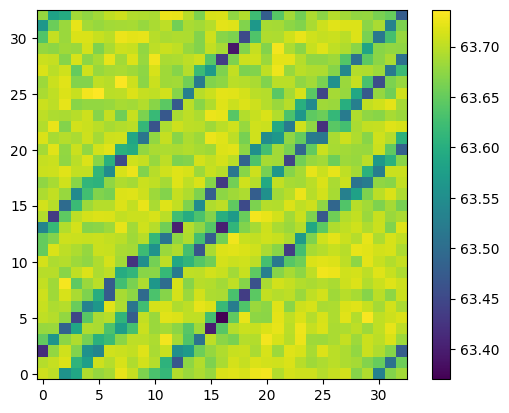

In [67]:
stokes, antiStokes = np.split(parameters_gauss, 2, axis=0)

fit_result_stokes = stokes.reshape((real_data.brillouinChannel.displayData.shape[0:-1] + (-1,)))
fit_result_antiStokes = antiStokes.reshape((real_data.brillouinChannel.displayData.shape[0:-1] + (-1,)))

shift_avg = (np.abs(fit_result_stokes[...,1]) + np.abs(fit_result_antiStokes[...,1]))/2

plt.imshow(shift_avg[10,:,:], origin='lower')
plt.colorbar()